In [1]:
# Install if needed
!pip install ucimlrepo -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, classification_report

# Load dataset
credit = fetch_ucirepo(id=350)
X = credit.data.features
y = credit.data.targets
df = pd.concat([X, y], axis=1)
df.columns = [*X.columns, 'default']
print(df.shape)
df.head()

(30000, 24)


,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,X15,X16,X17,X18,X19,X20,X21,X22,X23,default
0,20000,2,2,1,24,2,2,-1,-1,-2,...,0,0,0,0,689,0,0,0,0,1
1,120000,2,2,2,26,-1,2,0,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,90000,2,2,2,34,0,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,50000,2,2,1,37,0,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,50000,1,2,1,57,-1,0,-1,0,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


## Project Proposal

**Prediction Question:** Can we predict whether a credit card client will default on their payment next month based on their payment history, bill amounts, and demographic information?

**Prediction vs. Causation:** This is a predictive model — it identifies patterns associated with default risk. It does not establish causal relationships between any feature and default behavior.

**Dataset:** UCI Default of Credit Card Clients (ID=350)
- Source: https://archive.ics.uci.edu/dataset/350/default+of+credit+card+clients
- N = 30,000 observations, 23 features, 1 binary target (default: yes/no)
- Accessed: April 19, 2026

**Stakeholder:** This analysis would help a retail bank's credit risk team decide whether to approve or flag a client's account for early intervention before a default occurs.

In [2]:
 # EDA — Basic description
print("Shape:", df.shape)
print("\nData Types:\n", df.dtypes)
print("\nMissing Values:\n", df.isnull().sum())
print("\nTarget Distribution:\n", df['default'].value_counts())
print("\nBasic Stats:\n", df.describe())

Shape: (30000, 24)

Data Types:
 X1         int64
X2         int64
X3         int64
X4         int64
X5         int64
X6         int64
X7         int64
X8         int64
X9         int64
X10        int64
X11        int64
X12        int64
X13        int64
X14        int64
X15        int64
X16        int64
X17        int64
X18        int64
X19        int64
X20        int64
X21        int64
X22        int64
X23        int64
default    int64
dtype: object

Missing Values:
 X1         0
X2         0
X3         0
X4         0
X5         0
X6         0
X7         0
X8         0
X9         0
X10        0
X11        0
X12        0
X13        0
X14        0
X15        0
X16        0
X17        0
X18        0
X19        0
X20        0
X21        0
X22        0
X23        0
default    0
dtype: int64

Target Distribution:
 default
0    23364
1     6636
Name: count, dtype: int64

Basic Stats:
                    X1            X2            X3            X4            X5  \
count    30000.000000  3000

## Data Quality Summary

- Shape: 30,000 rows × 24 columns
- Missing values: None (0 across all columns)
- Missing data strategy: N/A — dataset is complete (MCAR/MAR/MNAR framework not applicable)
- Target variable: Binary (0 = no default, 1 = default)
- Class imbalance: 77.9% no default, 22.1% default — imbalance noted, will monitor precision/recall carefully
- All features are numeric; no encoding required

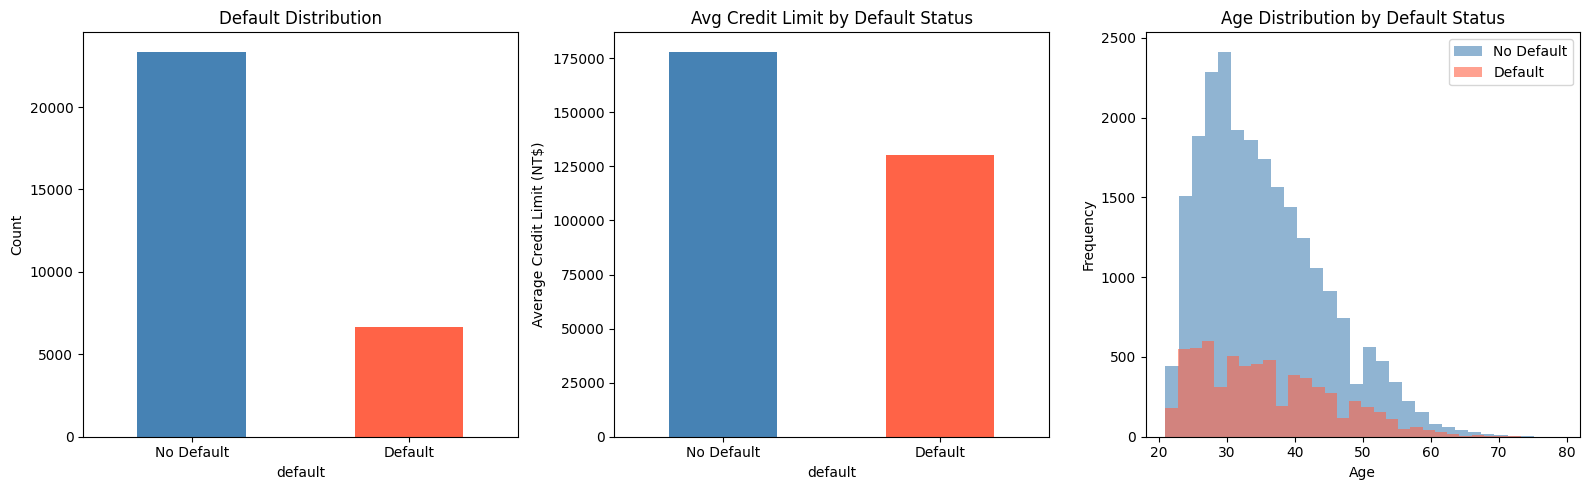

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Plot 1: Target distribution
df['default'].value_counts().plot(kind='bar', ax=axes[0], color=['steelblue', 'tomato'])
axes[0].set_title('Default Distribution')
axes[0].set_xticklabels(['No Default', 'Default'], rotation=0)
axes[0].set_ylabel('Count')

# Plot 2: Credit limit by default status
df.groupby('default')['X1'].mean().plot(kind='bar', ax=axes[1], color=['steelblue', 'tomato'])
axes[1].set_title('Avg Credit Limit by Default Status')
axes[1].set_xticklabels(['No Default', 'Default'], rotation=0)
axes[1].set_ylabel('Average Credit Limit (NT$)')

# Plot 3: Age distribution by default
df[df['default']==0]['X5'].plot(kind='hist', ax=axes[2], alpha=0.6, color='steelblue', label='No Default', bins=30)
df[df['default']==1]['X5'].plot(kind='hist', ax=axes[2], alpha=0.6, color='tomato', label='Default', bins=30)
axes[2].set_title('Age Distribution by Default Status')
axes[2].set_xlabel('Age')
axes[2].legend()

plt.tight_layout()
plt.show()

## EDA Visualizations

**Plot 1 — Default Distribution:** The dataset is imbalanced — 77.9% of clients did not default vs. 22.1% who did. This means accuracy alone is a misleading metric; we will prioritize precision and recall.

**Plot 2 — Avg Credit Limit by Default Status:** Clients who defaulted had a lower average credit limit (~NT$130,000) compared to non-defaulters (~NT$175,000), suggesting credit limit is a meaningful predictor of default risk.

**Plot 3 — Age Distribution by Default Status:** Both groups skew toward younger clients (peak ~30), but the distributions are similar in shape. Age alone is unlikely to be a strong predictor.

In [4]:
from sklearn.preprocessing import StandardScaler

# Train/test split
X_model = df.drop('default', axis=1)
y_model = df['default']

X_train, X_test, y_train, y_test = train_test_split(
    X_model, y_model, test_size=0.2, random_state=42
)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Logistic Regression baseline
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)
y_pred = lr.predict(X_test_scaled)

print("=== Logistic Regression Baseline ===")
print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred):.4f}")
print("\nFull Report:")
print(classification_report(y_test, y_pred))

=== Logistic Regression Baseline ===
Accuracy:  0.8100
Precision: 0.6927
Recall:    0.2369

Full Report:
              precision    recall  f1-score   support

           0       0.82      0.97      0.89      4687
           1       0.69      0.24      0.35      1313

    accuracy                           0.81      6000
   macro avg       0.76      0.60      0.62      6000
weighted avg       0.79      0.81      0.77      6000



 ## Preliminary Model Results — Logistic Regression Baseline

- Train/test split: 80/20, random_state=42
- Accuracy: 0.8100
- Precision (default class): 0.6927
- Recall (default class): 0.2369

**Interpretation:** The model achieves 81% accuracy, but the low recall on the default class (0.24) indicates it misses the majority of actual defaulters. This is expected given class imbalance (22% default rate). The final model will explore techniques to improve recall on the minority class. A second model (Random Forest or Decision Tree) will be compared in the final submission.